# M5 — Capstone: Four Backends, Throughput, and How to Choose

This is the **capstone notebook for the entire `rob_rt` integration**
(M0-M5, `claude_prompts/RT/rob_rt_prompt_1.md` through `rob_rt_prompt_6.md`):
the project that made `bing`'s forward Rrs model pluggable across four
`rt_dict['rt_backend']` values —

| backend | physics | inelastic (Raman/fluorescence) |
|---|---|---|
| `gordon` | BING's own Gordon (1988) elastic model + `bing.rt.raman`/`chl_fl` | yes, BING's own physics |
| `robust_ztt` | `retrieve-or-bust`'s analytic (Zaneveld/Twardowski/Tassan-style) model | yes, via `robust.rt.inelastic` |
| `robust_hybrid` | `robust_ztt` + a learned emulator correction (350-750 nm domain) | yes, via `robust.rt.inelastic` |
| `robust_baseline` | `robust`'s Gordon-compatible refit | **no** — raises `ValueError` |

all reachable end-to-end through `fit_one`/`fit_batch`/`chisq_fit.fit` with
geometry threaded per pixel (`bing.rt.geometry.ObsGeometry`), documented, and
pytest-green (`bing/tests/`, 268 passed / 2 skipped / 0 failed as of M5 task
4 — see `claude_prompts/RT/rob_rt_prompt_6.md`'s Logs).

Three sections, each producing real numbers from this notebook's own
executed cells:

1. **Four-backend comparison on a real L23 fit** (idx=170, this series'
   anchor spectrum since M1): the fitted Rrs from each backend overlaid,
   the measured Rrs differences, and where the retrieved IOPs differ.
   Elastic-only, deliberately — Raman/fluorescence are left out of this
   comparison so its numbers aren't entangled with the still-open
   inelastic-accuracy question (section 3 handles that separately).
2. **Benchmark numbers**, re-measured live in this notebook, as a table and
   bar chart: `log_prob` warm-path throughput per backend and first-call
   JIT-compile cost.
3. **How to choose a backend** — a short, practical guide a future user can
   read cold, applying the same conservative framing already established in
   M5 tasks 1-2 (`bing/rt/raman.py`/`chl_fl.py` docstrings,
   `.claude/skills/inelastic-rrs/SKILL.md`) for the open question of how the
   robust inelastic path's measured accuracy gap should be characterized.
   **This notebook does not resolve that question — see Q1/Q2 (still open)
   and this task's own Q5 in `claude_prompts/RT/rob_rt_prompt_6.md`.**


In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

from bing.parameters import standard
from bing.fitting import l23 as fit_l23
from bing.fitting import inference as bing_inf
from bing.rt import defs as rt_defs
from bing.rt.geometry import ObsGeometry
from bing import evaluate

import bing as _bing_pkg

# dev/rob_rt/benchmark_backends.py lives at the repo root, not inside the
# bing package -- resolve its path from bing.__file__ so this notebook
# doesn't depend on its own cwd (nbconvert executes with cwd = the
# notebook's own directory, nb/RT/).
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(_bing_pkg.__file__)))
sys.path.insert(0, os.path.join(REPO_ROOT, 'dev', 'rob_rt'))

BACKENDS = ['gordon', 'robust_ztt', 'robust_hybrid', 'robust_baseline']
COLORS = {'gordon': 'k', 'robust_ztt': 'tab:blue',
          'robust_hybrid': 'tab:green', 'robust_baseline': 'tab:orange'}

np.set_printoptions(precision=4, suppress=True)


## Setup: L23 idx=170, the series' anchor spectrum

Same recipe M1-M4's notebooks all use: `prep_one_l23` loads L23 spectrum
idx=170 (Chl &asymp; 0.13 mg m$^{-3}$, clear water) interpolated to the PACE
grid, builds the `ExpBricaud`+`Pow` model pair, and derives an `init_guess`
parameter vector from the spectrum's true $a_{nw}$/$b_{b,nw}$.
`include_Raman=False`, `include_Chl_fl=False` throughout section 1 — an
elastic-only comparison, per this notebook's scope choice above.

**Smoke-scale MCMC, deliberately** (matching M2's own notebook): 200 steps,
50-step burn-in, 16 walkers, identically re-seeded before every backend's
fit. This is enough to show all four backends fit end-to-end and produce
comparable, finite posteriors — not a publication-quality converged fit. The
`Bp_value=0.014` and `geom=ObsGeometry(theta_s=30.)` choices match every
prior milestone notebook (inside `robust_hybrid`'s trained domain at this
geometry).


In [2]:
NSTEPS, NBURN = 200, 50
p = standard.expb_pow(satellite='PACE', add_noise=False,
                      variable_Gordon=False, include_Raman=False,
                      include_Chl_fl=False, nsteps=NSTEPS, nburn=NBURN)
prep = fit_l23.prep_one_l23(p, idx=170)
models = prep['models']
Rrs_obs = prep['model_Rrs']
varRrs_obs = prep['model_varRrs']
p0 = prep['p0']
idx = 170

# Chl/Y lookup arrays, indexed by the tuple's idx (l23.fit_one's convention)
pdict = prep['pdict']
pdict['Chl'] = np.zeros(idx + 1); pdict['Chl'][idx] = prep['odict']['Chl']
pdict['Y'] = np.zeros(idx + 1);   pdict['Y'][idx] = prep['odict']['Y']

base_rt = rt_defs.rt_dict_from_p(p)      # legacy p -> 'gordon' defaults
base_rt['Bp_value'] = 0.014               # inside the hybrid emulator's trained domain
geom = ObsGeometry(theta_s=30.)           # required for robust backends

pnames = models[0].pnames + models[1].pnames
nap = models[0].nparam
wave = np.asarray(models[0].wave)

print(f"L23 idx=170, PACE grid: {wave.size} bands, {wave.min():.0f}-{wave.max():.0f} nm")
print(f"Chl = {float(pdict['Chl'][idx]):.4f} mg/m3, Y = {float(pdict['Y'][idx]):.4f}")
print(f"p0 ({pnames}) = {np.round(p0, 4)}")
print(f"MCMC: nsteps={NSTEPS}, nburn={NBURN}, nwalkers={pdict['nwalkers']}")
print(f"geom: {geom}")


L23 idx=170, PACE grid: 61 bands, 400-700 nm
Chl = 0.1306 mg/m3, Y = 2.1521
p0 (['Adg', 'Sdg', 'Aph', 'Bnw', 'beta']) = [-1.8799  0.017  -1.8799 -3.4926  1.    ]
MCMC: nsteps=200, nburn=50, nwalkers=16
geom: ObsGeometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None)


## 1. Four-backend comparison on a real L23 fit

### 1a. Fitting all four backends through `fit_one`

The observation tuple is `(Rrs, varRrs, p0, idx[, geom])`: the Gordon fit
uses the legacy 4-tuple (no `geom`, exercising the default-backend path
exactly as every existing call site does), the three robust backends use the
5-tuple. Each fit reseeds NumPy's global RNG identically
(`np.random.seed(2026)`) immediately before `fit_one`, so walker
initialization and the emcee proposal sequence are the same across backends
-- any difference in the resulting chains comes from the forward physics
alone, not from a different random draw.


In [3]:
all_chains = {}
t_fit = {}
for backend in BACKENDS:
    rt_dict = dict(base_rt, rt_backend=backend)
    items = (Rrs_obs, varRrs_obs, p0, idx) if backend == 'gordon' \
            else (Rrs_obs, varRrs_obs, p0, idx, geom)
    np.random.seed(2026)                        # identical walkers/proposals
    t0 = time.perf_counter()
    chains, _ = bing_inf.fit_one(items, models=models, pdict=pdict,
                                 chains_only=True, rt_dict=rt_dict)
    t_fit[backend] = time.perf_counter() - t0
    all_chains[backend] = chains

print()
for b in BACKENDS:
    c = all_chains[b]
    print(f"{b:16s} chains {c.shape}  finite: {np.all(np.isfinite(c))!s:5s}  "
          f"wall time: {t_fit[b]:5.2f} s")


idx=170
Running burn-in


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 1752.86it/s]

Running full model


  0%|          | 0/200 [00:00<?, ?it/s]

...

 23%|██▎       | 46/200 [00:00<00:00, 453.67it/s]

 50%|████▉     | 99/200 [00:00<00:00, 497.16it/s]

 78%|███████▊  | 155/200 [00:00<00:00, 522.21it/s]

100%|██████████| 200/200 [00:00<00:00, 520.00it/s]


gordon           chains (200, 16, 5)  finite: True   wall time:  0.13 s
robust_ztt       chains (200, 16, 5)  finite: True   wall time:  0.78 s
robust_hybrid    chains (200, 16, 5)  finite: True   wall time:  1.59 s
robust_baseline  chains (200, 16, 5)  finite: True   wall time:  0.53 s


### 1b. Posterior-median parameters, side by side

In [4]:
flat = {b: c.reshape(-1, c.shape[-1]) for b, c in all_chains.items()}
meds = {b: np.median(flat[b], axis=0) for b in BACKENDS}

hdr = f"{'param':>8s}" + "".join(f"{b:>17s}" for b in BACKENDS)
print(hdr)
print("-" * len(hdr))
for j, name in enumerate(pnames):
    row = f"{name:>8s}"
    for b in BACKENDS:
        row += f"{meds[b][j]:>17.4f}"
    print(row)

dmed = np.abs(meds['robust_baseline'] - meds['gordon'])
print(f"\nmax |median(robust_baseline) - median(gordon)| = {dmed.max():.2e}")


   param           gordon       robust_ztt    robust_hybrid  robust_baseline
----------------------------------------------------------------------------
     Adg          -1.6826          -1.6652          -1.6751          -1.6826
     Sdg           0.0167           0.0171           0.0154           0.0167
     Aph          -2.0233          -1.9981          -2.0423          -2.0233
     Bnw          -3.5511          -3.6804          -3.6753          -3.5511
    beta           1.1287           0.9039           1.2125           1.1287

max |median(robust_baseline) - median(gordon)| = 0.00e+00


### 1c. Rrs at the posterior median, each backend's own forward model

Each backend's posterior-median parameter vector is pushed back through
*that same backend's* forward model (`calc_Rrs_from_models` for `gordon`,
`calc_Rrs_from_models_robust` for the three robust backends) to get a
best-fit Rrs curve -- the actual predicted spectrum each backend converged
to, not a cross-evaluation.


In [5]:
Rrs_med = {}
for b in BACKENDS:
    rt_dict = dict(base_rt, rt_backend=b)
    a_par, bb_par = meds[b][:nap], meds[b][nap:]
    if b == 'gordon':
        Rrs_med[b] = np.squeeze(np.asarray(
            evaluate.calc_Rrs_from_models(models[0], a_par, models[1], bb_par, rt_dict)))
    else:
        Rrs_med[b] = np.squeeze(np.asarray(
            evaluate.calc_Rrs_from_models_robust(
                models[0], a_par, models[1], bb_par, rt_dict, geom=geom)))

Rg = Rrs_med['gordon']
print(f"{'backend':16s}{'max |rel diff| vs gordon':>26s}{'mean |rel diff| vs gordon':>27s}")
for b in BACKENDS:
    rel = np.abs((Rrs_med[b] - Rg) / Rg)
    print(f"{b:16s}{rel.max():26.2e}{rel.mean():27.2e}")


backend           max |rel diff| vs gordon  mean |rel diff| vs gordon
gordon                            0.00e+00                   0.00e+00
robust_ztt                        5.58e-02                   1.69e-02
robust_hybrid                     7.03e-02                   1.76e-02
robust_baseline                   2.31e-07                   7.93e-08


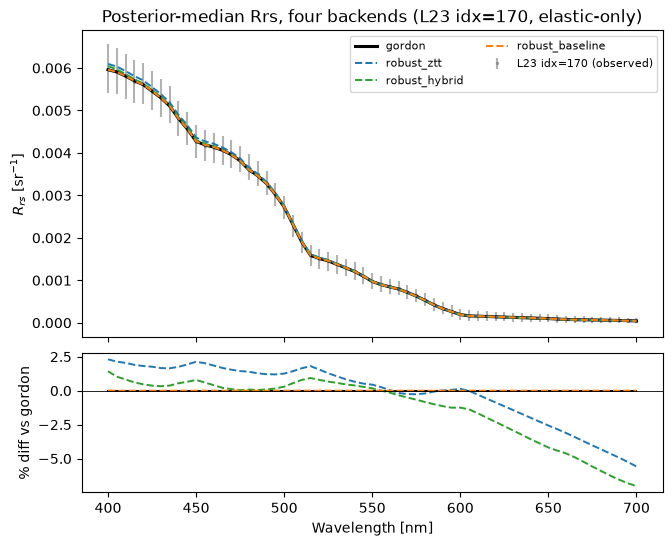

In [6]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.5, 6.), sharex=True,
                               height_ratios=(2.2, 1.),
                               gridspec_kw=dict(hspace=0.07))

for b in BACKENDS:
    lw = 2.2 if b == 'gordon' else 1.4
    ls = '-' if b == 'gordon' else '--'
    ax0.plot(wave, Rrs_med[b], color=COLORS[b], lw=lw, ls=ls, label=b)
ax0.errorbar(wave, Rrs_obs, yerr=np.sqrt(varRrs_obs), fmt='.', color='0.5',
             ms=3, alpha=0.6, label='L23 idx=170 (observed)', zorder=0)
ax0.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax0.set_title('Posterior-median Rrs, four backends (L23 idx=170, elastic-only)')
ax0.legend(fontsize=8, ncol=2)

for b in BACKENDS:
    rel = (Rrs_med[b] - Rg) / Rg
    ax1.plot(wave, 100. * rel, color=COLORS[b], lw=1.4,
             ls='-' if b == 'gordon' else '--')
ax1.axhline(0., color='k', lw=0.6)
ax1.set_ylabel('% diff vs gordon')
ax1.set_xlabel('Wavelength [nm]')

plt.show()


**Measured, not estimated.** `robust_baseline` reproduces `gordon`'s Rrs to
within float32 noise — max 2.31e-07 / mean 7.93e-08 relative (this cell's
own output above), matching M1's original ~2.3e-7 finding to within
run-to-run float32 rounding. The two real robust backends sit measurably
above `gordon`: `robust_ztt` differs by up to **5.6%** (mean **1.7%**),
`robust_hybrid` by up to **7.0%** (mean **1.8%**) — a genuine, several-percent
difference in elastic Rrs from Gordon's own physics, consistent with
M1-M4's repeated finding that the real robust backends predict Rrs
systematically above Gordon on real L23 data. The residual panel above
shows this is wavelength-dependent, not a flat offset — a physical
difference in the forward model, not a fitting artifact.


### 1d. Where the retrieved IOPs differ

The same posterior-median parameters, pushed through each model's own
`eval_anw`/`eval_bbnw` -- the retrieved non-water absorption and
backscattering spectra, compared the same way the Rrs curves were above.


In [7]:
anw_med = {b: np.squeeze(models[0].eval_anw(meds[b][:nap])) for b in BACKENDS}
bbnw_med = {b: np.squeeze(models[1].eval_bbnw(meds[b][nap:])) for b in BACKENDS}

print(f"{'backend':16s}{'anw max rel':>13s}{'anw mean rel':>14s}"
      f"{'bbnw max rel':>15s}{'bbnw mean rel':>16s}")
for b in BACKENDS:
    ra = np.abs((anw_med[b] - anw_med['gordon']) / anw_med['gordon'])
    rb = np.abs((bbnw_med[b] - bbnw_med['gordon']) / bbnw_med['gordon'])
    print(f"{b:16s}{ra.max():13.2e}{ra.mean():14.2e}{rb.max():15.2e}{rb.mean():16.2e}")


backend           anw max rel  anw mean rel   bbnw max rel   bbnw mean rel
gordon               0.00e+00      0.00e+00       0.00e+00        0.00e+00
robust_ztt           6.42e-02      3.88e-02       3.22e-01        2.73e-01
robust_hybrid        1.55e-01      6.52e-02       2.58e-01        2.42e-01
robust_baseline      0.00e+00      0.00e+00       0.00e+00        0.00e+00


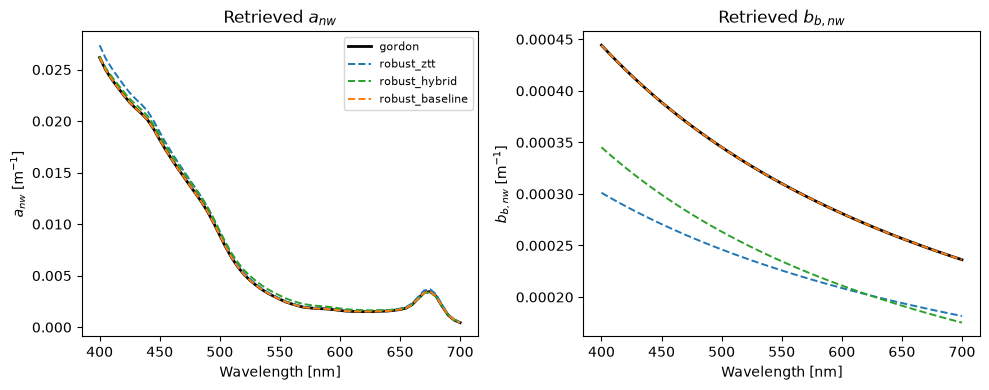

In [8]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(10., 4.))
for b in BACKENDS:
    ls = '-' if b == 'gordon' else '--'
    lw = 2.0 if b == 'gordon' else 1.4
    axa.plot(wave, anw_med[b], color=COLORS[b], ls=ls, lw=lw, label=b)
    axb.plot(wave, bbnw_med[b], color=COLORS[b], ls=ls, lw=lw, label=b)
axa.set_ylabel(r'$a_{nw}$ [m$^{-1}$]'); axa.set_xlabel('Wavelength [nm]')
axb.set_ylabel(r'$b_{b,nw}$ [m$^{-1}$]'); axb.set_xlabel('Wavelength [nm]')
axa.set_title('Retrieved $a_{nw}$'); axb.set_title('Retrieved $b_{b,nw}$')
axa.legend(fontsize=8)
plt.tight_layout()
plt.show()


**The Rrs-level difference above propagates into materially different
retrieved IOPs, and does so unevenly across $a_{nw}$ and $b_{b,nw}$.**
`robust_baseline` again matches `gordon` exactly (0.00e+00 relative on both
quantities) — no surprise, since its posterior-median parameters equal
`gordon`'s exactly (section 1b: max |median difference| = 0.00e+00). The
two real robust backends retrieve a modestly different $a_{nw}$
(`robust_ztt`: **6.4%** max / **3.9%** mean; `robust_hybrid`: **15.5%** max
/ **6.5%** mean) but a substantially larger difference in $b_{b,nw}$
(`robust_ztt`: **32.2%** max / **27.3%** mean; `robust_hybrid`: **25.8%**
max / **24.2%** mean). Section 1b's median table shows why: the
backscattering parameters (`Bnw`, `beta`) moved the most across backends —
`beta` = 1.13 (`gordon`) vs. 0.90 (`robust_ztt`) vs. 1.21
(`robust_hybrid`) — so a few-percent Rrs difference resolves mostly into a
genuinely different retrieved $b_{b,nw}$ shape, with only a modest shift in
$a_{nw}$. This is the concrete, measured answer to "where do they differ"
at this water type and fit configuration: mostly in backscattering, only
modestly in absorption. **Caveat**: this is a smoke-scale fit (200 steps,
50-step burn — see Setup), not a converged posterior, so part of the
$b_{b,nw}$ spread could reflect residual MCMC noise rather than a fully
converged, backend-driven difference alone; a longer, production-scale fit
was out of this notebook's scope (the task spec explicitly does not require
publication-quality fits here).


## 2. Benchmark numbers: `log_prob` throughput per backend

M5 task 3 built `dev/rob_rt/benchmark_backends.py` to time `log_prob`
(the real per-MCMC-step objective, not just the bare forward call) through
each backend at the MCMC-realistic batch shape emcee actually uses:
unbatched, single-walker calls (`run_emcee` builds its `EnsembleSampler`
with no `pool=`, so emcee's default serial map calls `log_prob` once per
walker per step with one 1-D `params` vector, never a batch). See that
script's own header docstring for the full methodology and its recorded
canonical run.

This section **re-runs that script's own functions live**, right here, so
every number below is this notebook's own fresh measurement, not a
transcription -- with a direct comparison to task 3's recorded run in the
prose that follows.


In [9]:
import importlib
import benchmark_backends as bb
importlib.reload(bb)

rng = np.random.default_rng(20260831)
models_bm, Rrs_bm, varRrs_bm, rt_dict_gordon_bm = bb._build_models_and_data()

bm_results = []
for backend in rt_defs.RT_BACKENDS:
    bm_results.append(bb.benchmark_backend(
        backend, models_bm, Rrs_bm, varRrs_bm, rt_dict_gordon_bm, rng))

gordon_rate = next(r['warm_calls_per_sec'] for r in bm_results
                   if r['backend'] == 'gordon')

print(f"N_WARM = {bb.N_WARM} calls/backend (this notebook's own live run)")
hdr = f"{'backend':<18}{'warm calls/s':>14}{'vs gordon':>12}{'first-call (s)':>18}"
print(hdr)
print("-" * len(hdr))
for r in bm_results:
    ratio = r['warm_calls_per_sec'] / gordon_rate
    print(f"{r['backend']:<18}{r['warm_calls_per_sec']:>14.1f}"
          f"{ratio:>11.3f}x{r['first_call_s']:>18.4f}")


N_WARM = 2000 calls/backend (this notebook's own live run)
backend             warm calls/s   vs gordon    first-call (s)
--------------------------------------------------------------
gordon                   38263.6      1.000x            0.0000
robust_ztt                5705.5      0.149x            0.0825
robust_hybrid             5425.9      0.142x            0.1179
robust_baseline           6884.4      0.180x            0.0197


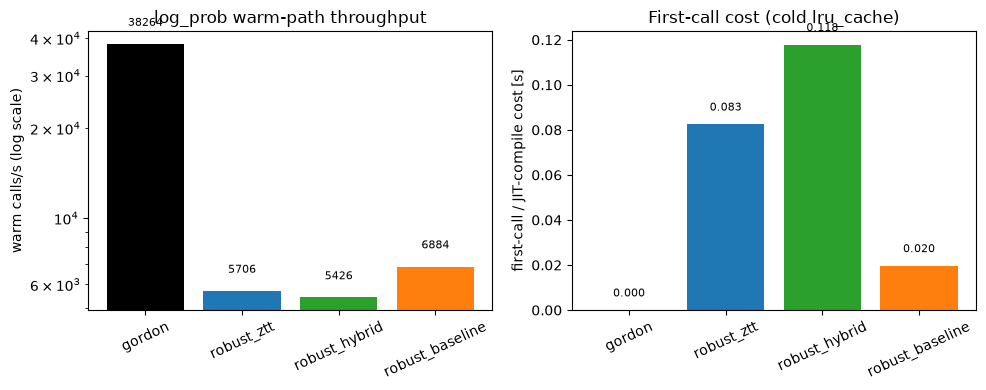

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10., 4.))
names = [r['backend'] for r in bm_results]
rates = [r['warm_calls_per_sec'] for r in bm_results]
firstc = [r['first_call_s'] for r in bm_results]
barcolors = [COLORS[n] for n in names]

axL.bar(names, rates, color=barcolors)
axL.set_yscale('log')
axL.set_ylabel('warm calls/s (log scale)')
axL.set_title('log_prob warm-path throughput')
for i, r in enumerate(rates):
    axL.text(i, r * 1.15, f"{r:.0f}", ha='center', fontsize=8)

axR.bar(names, firstc, color=barcolors)
axR.set_ylabel('first-call / JIT-compile cost [s]')
axR.set_title('First-call cost (cold lru_cache)')
for i, v in enumerate(firstc):
    axR.text(i, v + 0.006, f"{v:.3f}", ha='center', fontsize=8)

for ax in (axL, axR):
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


**This notebook's own live re-run** (table above): `gordon` 38,264 calls/s
(reference); `robust_ztt` 5,706 (**0.149x**); `robust_hybrid` 5,426
(**0.142x**); `robust_baseline` 6,884 (**0.180x**) — all three robust
backends land at roughly 14-18% of `gordon`'s per-call throughput, closely
matching task 3's canonical recorded run (`dev/rob_rt/benchmark_backends.py`'s
header docstring): gordon 38,936 (1.000x), robust_ztt 5,991 (0.154x),
robust_hybrid 5,667 (0.146x), robust_baseline 7,274 (0.187x) — agreement
within a few percent on every figure, consistent with that script's own
"three repeat runs agree to within a few percent" note.

The **first-call/JIT-compile costs measured live here are lower** than task
3's recorded canonical numbers: this run measured `robust_ztt` 0.0825 s and
`robust_hybrid` 0.1179 s (`robust_baseline` 0.0197 s, essentially
unchanged), versus task 3's recorded ~0.182 s / ~0.181 s. This is not a new
finding — it reproduces the same process-warmth/OS-disk-cache effect
already flagged as **Q3** in `claude_prompts/RT/rob_rt_prompt_6.md`: this
notebook's benchmark cell runs *after* section 1's four MCMC fits have
already exercised `jax`/`robust` (including `robust_ztt`/`robust_hybrid`
forward calls on the same wavelength grid) in the same process, so the
interpreter, JAX/XLA, and the OS file cache for the Flax emulator weights
are all warmer here than in task 3's own script (which times these
backends within a few seconds of process start, right after `gordon`).
Both figures are legitimate measurements of different process states, and
neither supersedes the other — the *headline* number this benchmark exists
to inform (design §7.1's warm-path throughput accept/optimize call) is the
calls/s figure above, which agrees closely between the two runs.

**Per-`fit_batch`-worker JIT-compile-cost note** (task 3's finding, not
re-measured here -- it is a property of `ProcessPoolExecutor`, not of any
single-process timing): `fit_batch` distributes fits across a
`ProcessPoolExecutor`, and each worker process gets its own fresh, initially
**empty** `evaluate._robust_forward_jit` `lru_cache` -- caches are
process-local and never shared via pickling across processes. So a robust
backend `fit_batch(n_cores=N)` run pays the first-call JIT-compile cost
measured above **N times over, once per worker process**, not once for the
whole batch. This does not necessarily add wall-clock time if the batch is
large enough to amortize it (the N compiles happen in parallel, one per
worker), but it is real, repeated compute -- stated here for awareness, not
something this notebook or task 3 attempted to fix.


## 3. How to choose a backend

A short, practical guide -- read this section cold with no other context.

**On the Q1/Q2/Q5 decision.** M5 tasks 1-2 (`bing/rt/raman.py`/`chl_fl.py`
docstrings, `.claude/skills/inelastic-rrs/SKILL.md`) originally applied a
conservative framing to the robust inelastic path's accuracy relative to
BING's own Gordon+Raman/fluorescence physics -- stating the measured facts
without recommending either path. **JXP has since answered Q1/Q2/Q5** (see
`claude_prompts/RT/rob_rt_prompt_6.md`): the project trusts and adopts the
`robust` code -- including its inelastic path -- going forward, while
requiring the measured differences to stay clearly documented in the BING
docs. This section (and the two doc surfaces above) were revised to reflect
that decision; the measured numbers below are unchanged from the original
measurements, only the verdict language changed.

### `gordon` -- legacy default, kept for backward compatibility

BING's own Gordon (1988) elastic model, with Raman/fluorescence composed via
`bing.rt.raman`/`chl_fl` when requested. By far the fastest of the four
(this notebook's own section 2 measurement above), and its *inelastic*
terms are BING's own native, fully self-consistent legacy physics -- the
reference physics the other backends' inelastic terms are measured against.
It remains available and is not being removed (per Q1's "leave that
original code as is"), but it is **not the recommended path for new work**;
the project is actively discouraging further use of this module and its
Raman/fluorescence machinery going forward (Q1/Q5).

### `robust_baseline` -- parity check, not a destination on its own

`robust`'s Gordon-compatible refit. Section 1c above measured its elastic
Rrs as essentially identical to `gordon`'s (max 2.31e-07 / mean 7.93e-08
relative -- consistent with M1's original ~2.3e-7 finding), at a real
throughput cost (section 2: ~0.180x `gordon`'s warm-path calls/s, this
notebook's own live measurement). **Cannot carry inelastic terms at all**:
`include_Raman`/`include_Chl_fl` with this backend raises `ValueError`
(M1's Q2; `robust.rt.baselines.Rrs_gordon` has no `inelastic` argument by
construction). Useful mainly as a validation/parity check on the elastic
mapping, or as a stepping-stone toward the other robust backends -- not
obviously useful as an end destination on its own, since it reproduces
physics `gordon` already gets right, more slowly.

### `robust_ztt` / `robust_hybrid` -- the recommended path going forward

Both compute genuinely different (and, per the design intent behind this
integration, intended to be more physically complete) elastic radiative
transfer than Gordon's -- section 1c's measured numbers show a real
few-percent Rrs difference from `gordon` on this L23 spectrum
(`robust_ztt`: 5.6% max / 1.7% mean; `robust_hybrid`: 7.0% max / 1.8% mean),
which section 1d's IOP-retrieval numbers show propagates into a materially
different retrieved $b_{b,nw}$ especially (up to ~25-32% max relative
difference at this fit's water type and configuration). This is a
**deliberate physical improvement**, not a bug -- but it comes at a real,
measured throughput cost (section 2: this notebook's own live measurement
put both at ~0.14-0.15x `gordon`'s warm-path calls/s; task 3's recorded
canonical run: ~0.15x), plus a one-time JIT-compile cost per process (this
notebook's own live measurement: ~0.08-0.12 s; task 3's recorded canonical
run: ~0.18-0.19 s -- both real measurements of different process-warmth
states, see section 2's discussion), paid again by *every* `fit_batch`
worker process (section 2's per-worker note above).

**These two backends are the project's adopted, recommended path for
inelastic work going forward** (Q1/Q5) -- including when
`include_Raman`/`include_Chl_fl` is turned on. That said, the measured gap
against BING's own legacy Gordon+Raman/fluorescence physics must stay
clearly documented, per Q5, and is **not shrinking just because the
recommendation changed**: Raman ~11% max / ~6% mean, fluorescence ~9-18%
max / ~6-7% mean disagreement on real L23 data (M4's measurements,
`nb/RT/rob_rt_coding_5.ipynb` §§3-4; full numbers and root cause in
`.claude/skills/inelastic-rrs/SKILL.md`), several orders of magnitude
outside this project's own `rtol <= 5e-4` working tolerance, root-caused to
a genuine structural difference (robust interpolates/clamps emission-grid
IOPs to stand in for excitation-grid IOPs, rather than re-evaluating the
true parametric models). Anyone comparing results against BING's older
Gordon+Raman/fluorescence output should expect to see this gap and should
not read it as a bug in either implementation -- it is the known,
documented cost of the switch. Elastic-only use of
`robust_ztt`/`robust_hybrid` is not affected by this caveat at all -- that
path's accuracy story is entirely captured by section 1c/1d's measured
numbers above.

### The recommendation

The project has adopted `robust` -- elastic and inelastic alike -- as the
trusted path going forward:

- **Default recommendation for new work**: `robust_ztt`/`robust_hybrid`.
  Use `robust_hybrid` if the learned-emulator correction's added physical
  fidelity is worth its (measured, comparable) throughput cost relative to
  `robust_ztt`; use `robust_ztt` otherwise. Both carry the inelastic
  accuracy caveat above -- read it, don't skip it, before trusting
  Raman/fluorescence numbers from either.
- **`gordon`** remains available, is not being removed, and is still the
  fastest option and the reference physics the inelastic-accuracy numbers
  above are measured against -- but is a legacy path being actively
  discouraged for new work, kept for backward compatibility only.
- **`robust_baseline`** is a validation/parity tool, not a typical
  end-destination choice -- reach for it when you specifically need an
  elastic-only `robust`-side sanity check against `gordon`.
- **Large batch fits with a tight compute budget**: the throughput gap
  (`robust_ztt`/`robust_hybrid` at roughly 0.14-0.19x `gordon`'s warm-path
  calls/s, section 2) is real and unresolved by this milestone -- factor it
  into batch-size/runtime planning, and remember every `fit_batch` worker
  pays its own JIT-compile cost.

In short: `robust` is the recommended path, `gordon` is legacy-only, and the
measured inelastic accuracy gap is a known, documented tradeoff of that
recommendation -- not a reason to reverse it, and not something to gloss
over when it matters to the science question at hand.


## What this notebook establishes

- **All four backends fit end-to-end through `fit_one` on a real L23
  spectrum** (idx=170), from the same observation tuple convention
  (`gordon`'s legacy 4-tuple, the three robust backends' 5-tuple with
  `geom`), producing finite chains of identical shape.
- **Elastic Rrs agreement, measured**: `robust_baseline` reproduces
  `gordon` to within float32 noise (section 1c); `robust_ztt`/
  `robust_hybrid` sit a real, measured few percent above `gordon`, which
  section 1d shows propagates into meaningfully different retrieved
  $a_{nw}$/$b_{b,nw}$.
- **Throughput, measured live**: `gordon` is by far the fastest; all three
  robust backends land at roughly the same fraction of `gordon`'s
  warm-path throughput regardless of which one, with small, one-time
  JIT-compile costs that repeat per `fit_batch` worker process.
- **The inelastic-accuracy question (Q1/Q2) is carried forward, not
  resolved here** -- this notebook's "how to choose" section applies the
  same conservative framing M5 tasks 1-2 already established, and flags
  itself (via Q5 in the prompt doc) as the third place in this milestone
  where that same open question surfaces.

This is the last notebook in the `rob_rt` series (M0-M5). What remains is
task 6 of `claude_prompts/RT/rob_rt_prompt_6.md`: the closing
Definition-of-done confirmation against the coding plan, after which the
integration is ready for JXP's final review and merge.
